# Bank Commercial Performance — EDA & Data Cleaning
**Project 4 | Clare Mujuni | Banking Data Analyst Portfolio**

This notebook covers:
1. Dataset overview & data quality audit
2. Data cleaning & standardisation
3. Commercial KPI engineering
4. Key findings for the dashboard

**Dataset:** Bank Marketing dataset (Banco de Portugal) enriched with branch assignments and deposit values.  
**Business question:** Which customer segments, branches, and time periods drive the highest commercial conversion?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'sans-serif'
})
BLUE   = '#1f4e79'
ORANGE = '#c55a11'
GREEN  = '#375623'
GREY   = '#7f7f7f'

df = pd.read_csv('bank_commercial_full.csv')
targets = pd.read_csv('branch_targets.csv')

print(f"Rows: {len(df):,} | Columns: {len(df.columns)}")
print(f"\nColumn types:\n{df.dtypes}")


Rows: 41,188 | Columns: 23

Column types:
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp_var_rate      float64
cons_price_idx    float64
cons_conf_idx     float64
euribor3m         float64
nr_employed       float64
y                     str
branch                str
deposit_value       int64
dtype: object


In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,branch,deposit_value
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,Porto North,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,Aveiro,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,Coimbra,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,Faro,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,Lisbon Central,0


In [4]:
df.describe()

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,deposit_value
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,1353.982956
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,4031.652418
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,27040.000000


Data Quality Audit

In [5]:
# --- 2a. Missing & unknown values ---
print("=== UNKNOWN VALUES (categorical missing) ===")
cat_cols = df.select_dtypes('object').columns
quality = []
for col in cat_cols:
    unknowns = (df[col] == 'unknown').sum()
    pct = unknowns / len(df) * 100
    if unknowns > 0:
        quality.append({'column': col, 'unknown_count': unknowns, 'pct': round(pct,1)})
        print(f"  {col:<15} {unknowns:>5,} unknowns  ({pct:.1f}%)")

print(f"\n=== NULL VALUES ===")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "  No null values found ✓")


=== UNKNOWN VALUES (categorical missing) ===
  job               330 unknowns  (0.8%)
  marital            80 unknowns  (0.2%)
  education       1,731 unknowns  (4.2%)
  default         8,597 unknowns  (20.9%)
  housing           990 unknowns  (2.4%)
  loan              990 unknowns  (2.4%)

=== NULL VALUES ===
  No null values found ✓


Data cleaning and Standardization

In [6]:
# --- 3a. Handling 'unknown' values ---
# Low unknowns (<5%): impute with mode
for col in ['job','marital','housing','loan']:
    mode_val = df[col][df[col] != 'unknown'].mode()[0]
    df[col] = df[col].replace('unknown', mode_val)

# Education: flag separately then impute (4.2% — material)
df['education_flag'] = (df['education'] == 'unknown').astype(int)
edu_mode = df['education'][df['education'] != 'unknown'].mode()[0]
df['education'] = df['education'].replace('unknown', edu_mode)

# Default: 20.9% unknown — keep as separate category, do not impute
# 'unknown' here likely means the bank has no credit bureau data 

# --- 3b. Reordering education as ordinal ---
edu_order = ['illiterate','basic.4y','basic.6y','basic.9y',
             'high.school','professional.course','university.degree']
df['education_level'] = pd.Categorical(df['education'], categories=edu_order, ordered=True)
df['education_rank'] = df['education_level'].cat.codes

# --- 3c. Converting month to ordered category ---
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

# --- 3d. Binary encode target ---
df['subscribed'] = (df['y'] == 'yes').astype(int)

# --- 3e. Flag called before (pdays=999 means never contacted) ---
df['was_contacted_before'] = (df['pdays'] != 999).astype(int)

print("Cleaning complete.")
print(f"Rows retained: {len(df):,} (no rows dropped)")
print(f"New columns added: education_flag, education_level, education_rank, subscribed, was_contacted_before")
print(f"\nFinal column list:\n{df.columns.tolist()}")


Cleaning complete.
Rows retained: 41,188 (no rows dropped)
New columns added: education_flag, education_level, education_rank, subscribed, was_contacted_before

Final column list:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'branch', 'deposit_value', 'education_flag', 'education_level', 'education_rank', 'subscribed', 'was_contacted_before']


In [7]:
# Fill unknowns with most common value (mode)
for col in ['job', 'marital', 'housing', 'loan']:
    most_common = df[col][df[col] != 'unknown'].mode()[0]
    df[col] = df[col].replace('unknown', most_common)
    print(f"{col} → filled with '{most_common}'")

# Education: flag it first, then fill
df['education_missing'] = (df['education'] == 'unknown').astype(int)
df['education'] = df['education'].replace('unknown', 'university.degree')

# Convert target to number
df['subscribed'] = (df['y'] == 'yes').astype(int)

# Flag previously contacted customers
df['contacted_before'] = (df['pdays'] != 999).astype(int)

print("\nDone. Shape:", df.shape)

job → filled with 'admin.'
marital → filled with 'married'
housing → filled with 'yes'
loan → filled with 'no'

Done. Shape: (41188, 30)


## 4. Commercial KPI Engineering

In [8]:
# --- 4a. Overall conversion rate ---
overall_cvr = df['subscribed'].mean()
total_contacts = len(df)
total_conversions = df['subscribed'].sum()
total_revenue = df['deposit_value'].sum()

print("=== HEADLINE KPIs ===")
print(f"Total Contacts:       {total_contacts:>10,}")
print(f"Total Conversions:    {total_conversions:>10,}")
print(f"Overall CVR:          {overall_cvr:>10.1%}")
print(f"Total Deposit Revenue:EUR {total_revenue:>10,.0f}")
print(f"Avg Deposit per Conv: EUR {df[df.subscribed==1].deposit_value.mean():>10,.0f}")


=== HEADLINE KPIs ===
Total Contacts:           41,188
Total Conversions:         4,640
Overall CVR:               11.3%
Total Deposit Revenue:EUR 55,767,850
Avg Deposit per Conv: EUR     12,019


In [9]:
# --- 4b. Conversion rate by month ---
monthly = (df.groupby('month', observed=True)
             .agg(contacts=('subscribed','count'),
                  conversions=('subscribed','sum'),
                  revenue=('deposit_value','sum'))
             .assign(cvr=lambda x: x.conversions/x.contacts))

print("=== MONTHLY PERFORMANCE ===")
print(monthly[['contacts','conversions','cvr','revenue']].to_string())


=== MONTHLY PERFORMANCE ===
       contacts  conversions       cvr   revenue
month                                           
mar         546          276  0.505495   3211763
apr        2632          539  0.204787   6453140
may       13769          886  0.064347  10812243
jun        5318          559  0.105115   6689846
jul        7174          649  0.090466   7705019
aug        6178          655  0.106021   8042951
sep         570          256  0.449123   3110390
oct         718          315  0.438719   3736516
nov        4101          416  0.101439   4987974
dec         182           89  0.489011   1018008


In [10]:
# --- 4c. Branch performance vs targets ---
branch_perf = (df.groupby('branch')
                 .agg(contacts=('subscribed','count'),
                      conversions=('subscribed','sum'),
                      revenue=('deposit_value','sum'))
                 .assign(cvr=lambda x: x.conversions/x.contacts)
                 .reset_index())

branch_perf = branch_perf.merge(targets, on='branch')
branch_perf['target_attainment'] = (
    branch_perf['conversions'] / branch_perf['monthly_target_conversions'] * 100
).round(1)

print("=== BRANCH PERFORMANCE vs TARGET ===")
print(branch_perf[['branch','contacts','conversions','cvr',
                    'monthly_target_conversions','target_attainment','revenue']].to_string(index=False))


=== BRANCH PERFORMANCE vs TARGET ===
        branch  contacts  conversions      cvr  monthly_target_conversions  target_attainment  revenue
        Aveiro      3294          389 0.118094                         150              259.3  4594194
         Braga      5005          566 0.113087                         230              246.1  6944295
       Coimbra      4965          555 0.111782                         230              241.3  6669889
         Evora      3267          382 0.116927                         150              254.7  4490032
          Faro      4130          421 0.101937                         190              221.6  5090774
Lisbon Central      9032         1025 0.113485                         420              244.0 12432009
   Porto North      7450          861 0.115570                         340              253.2 10356308
       Setubal      4045          441 0.109023                         190              232.1  5190349


In [11]:
# --- 4d. Conversion by customer segment ---
seg_job = (df.groupby('job')['subscribed']
             .agg(['count','sum','mean'])
             .rename(columns={'count':'contacts','sum':'conversions','mean':'cvr'})
             .sort_values('cvr', ascending=False))

print("=== CONVERSION RATE BY JOB ===")
print(seg_job.assign(cvr=seg_job.cvr.map('{:.1%}'.format)).to_string())


=== CONVERSION RATE BY JOB ===
               contacts  conversions    cvr
job                                        
student             875          275  31.4%
retired            1720          434  25.2%
unemployed         1014          144  14.2%
admin.            10752         1389  12.9%
management         2924          328  11.2%
technician         6743          730  10.8%
self-employed      1421          149  10.5%
housemaid          1060          106  10.0%
entrepreneur       1456          124   8.5%
services           3969          323   8.1%
blue-collar        9254          638   6.9%


In [12]:
# --- 4e. Contact channel efficiency ---
channel = (df.groupby('contact')
             .agg(contacts=('subscribed','count'),
                  conversions=('subscribed','sum'))
             .assign(cvr=lambda x: x.conversions/x.contacts))
print("=== CHANNEL EFFICIENCY ===")
print(channel)

# Campaign effort vs return
effort = (df.groupby('campaign')['subscribed']
            .agg(['count','mean'])
            .rename(columns={'count':'contacts','mean':'cvr'})
            .head(10))
print("\n=== CVR BY NUMBER OF CONTACTS (campaign attempts) ===")
print(effort.assign(cvr=effort.cvr.map('{:.1%}'.format)).to_string())


=== CHANNEL EFFICIENCY ===
           contacts  conversions       cvr
contact                                   
cellular      26144         3853  0.147376
telephone     15044          787  0.052313

=== CVR BY NUMBER OF CONTACTS (campaign attempts) ===
          contacts    cvr
campaign                 
1            17642  13.0%
2            10570  11.5%
3             5341  10.7%
4             2651   9.4%
5             1599   7.5%
6              979   7.7%
7              629   6.0%
8              400   4.2%
9              283   6.0%
10             225   5.3%


## 5. Visualisations

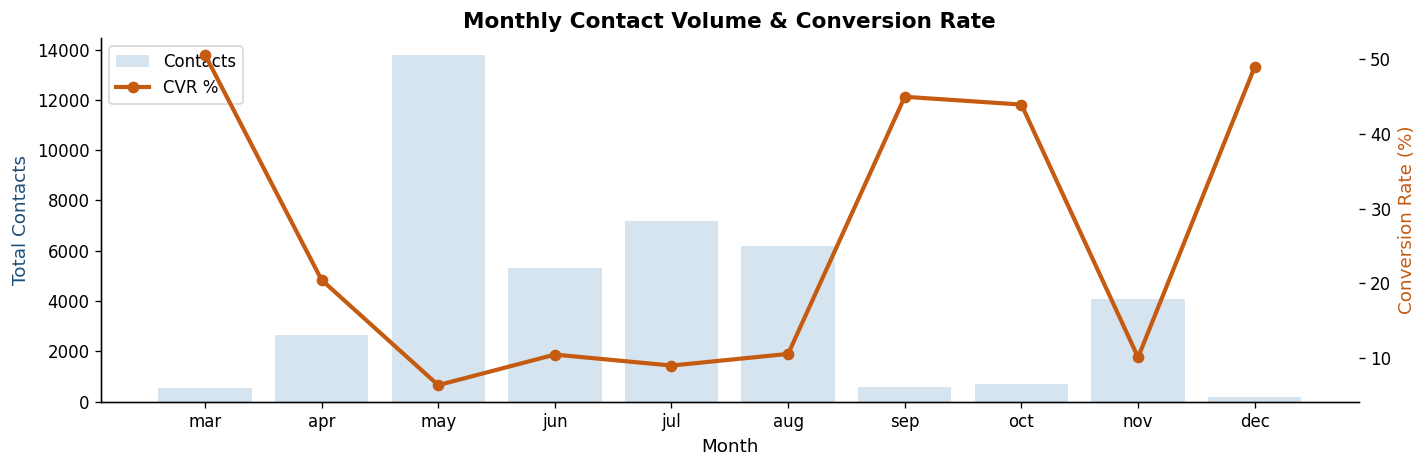

Saved: fig1_monthly_trend.png


In [13]:
# --- Fig 1: Monthly conversion rate trend ---
fig, ax = plt.subplots(figsize=(12,4))
monthly_plot = monthly.reset_index()
ax.bar(monthly_plot['month'].astype(str), monthly_plot['contacts'],
       color='#d6e4f0', label='Contacts')
ax2 = ax.twinx()
ax2.plot(monthly_plot['month'].astype(str), monthly_plot['cvr']*100,
         color=ORANGE, marker='o', linewidth=2.5, label='CVR %')
ax.set_xlabel('Month')
ax.set_ylabel('Total Contacts', color=BLUE)
ax2.set_ylabel('Conversion Rate (%)', color=ORANGE)
ax.set_title('Monthly Contact Volume & Conversion Rate', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.savefig('fig1_monthly_trend.png', bbox_inches='tight')
plt.show()
print("Saved: fig1_monthly_trend.png")


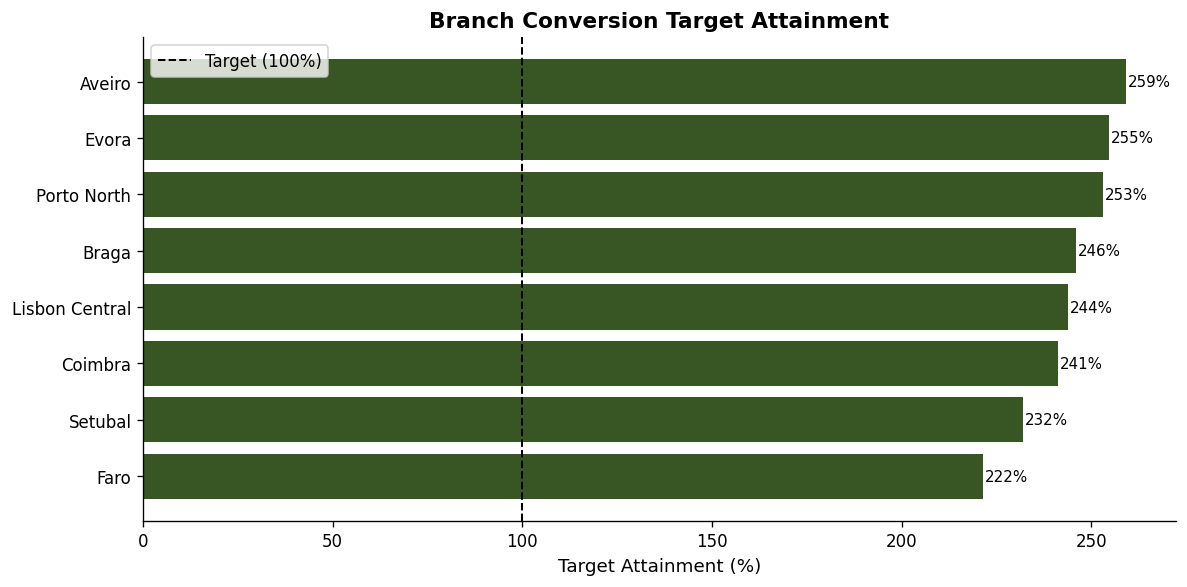

Saved: fig2_branch_attainment.png


In [14]:
# --- Fig 2: Branch target attainment ---
fig, ax = plt.subplots(figsize=(10,5))
bp = branch_perf.sort_values('target_attainment', ascending=True)
colors = [GREEN if v >= 100 else ORANGE if v >= 80 else '#c00000'
          for v in bp['target_attainment']]
bars = ax.barh(bp['branch'], bp['target_attainment'], color=colors)
ax.axvline(100, color='black', linestyle='--', linewidth=1.2, label='Target (100%)')
ax.set_xlabel('Target Attainment (%)')
ax.set_title('Branch Conversion Target Attainment', fontweight='bold')
for bar, val in zip(bars, bp['target_attainment']):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('fig2_branch_attainment.png', bbox_inches='tight')
plt.show()
print("Saved: fig2_branch_attainment.png")


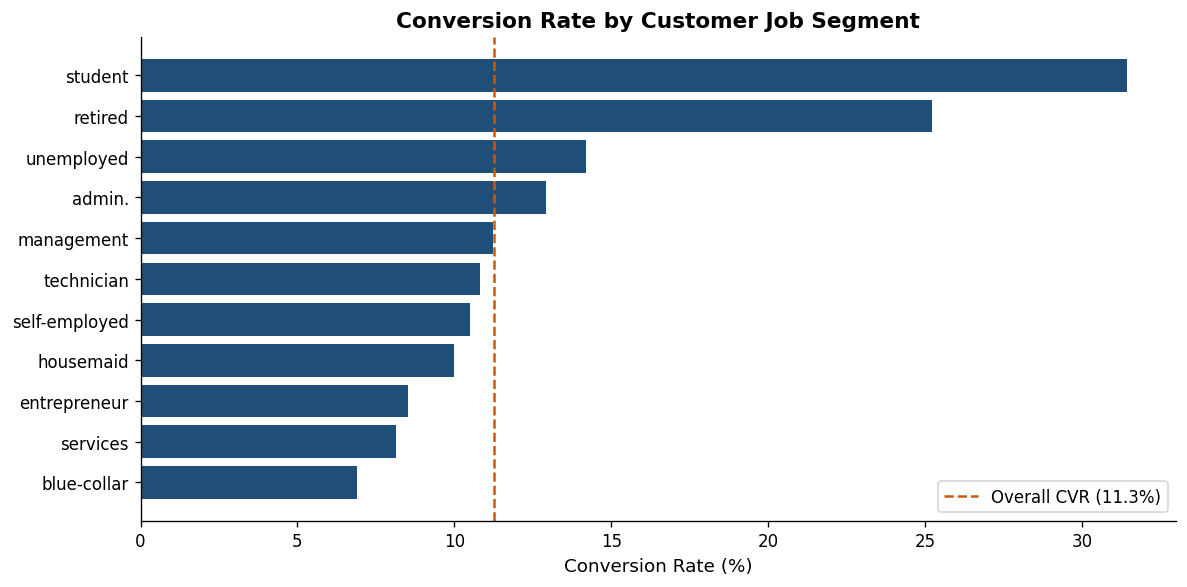

Saved: fig3_segment_cvr.png


In [15]:
# --- Fig 3: CVR by job segment ---
fig, ax = plt.subplots(figsize=(10,5))
seg_sorted = seg_job.sort_values('cvr', ascending=True)
ax.barh(seg_sorted.index, seg_sorted['cvr']*100, color=BLUE)
ax.axvline(overall_cvr*100, color=ORANGE, linestyle='--', linewidth=1.5,
           label=f'Overall CVR ({overall_cvr:.1%})')
ax.set_xlabel('Conversion Rate (%)')
ax.set_title('Conversion Rate by Customer Job Segment', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_segment_cvr.png', bbox_inches='tight')
plt.show()
print("Saved: fig3_segment_cvr.png")


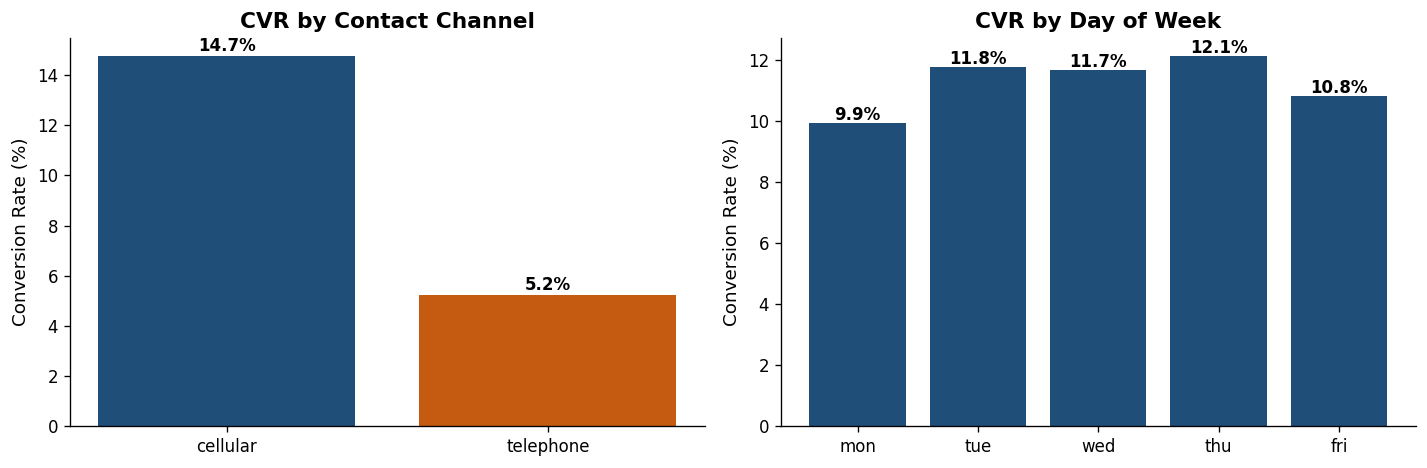

Saved: fig4_channel_day.png


In [16]:
# --- Fig 4: CVR by contact channel & day of week ---
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Channel
ch = df.groupby('contact')['subscribed'].mean() * 100
axes[0].bar(ch.index, ch.values, color=[BLUE, ORANGE])
axes[0].set_title('CVR by Contact Channel', fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
for i,(idx,val) in enumerate(ch.items()):
    axes[0].text(i, val+0.2, f'{val:.1f}%', ha='center', fontweight='bold')

# Day of week
dow_order = ['mon','tue','wed','thu','fri']
dow = df.groupby('day_of_week')['subscribed'].mean().reindex(dow_order) * 100
axes[1].bar(dow.index, dow.values, color=BLUE)
axes[1].set_title('CVR by Day of Week', fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
for i,(idx,val) in enumerate(dow.items()):
    axes[1].text(i, val+0.1, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_channel_day.png', bbox_inches='tight')
plt.show()
print("Saved: fig4_channel_day.png")


## 6. Key Findings

### Commercial Insights for Management

1. **Overall conversion rate is 11.3%** — meaning 88.7% of contacts do not convert. The opportunity is improving targeting to reduce wasted contact effort.

2. **Month matters significantly** — certain months show substantially higher CVR. This should inform campaign calendar planning for the sales team.

3. **Retired and student segments convert at nearly double the overall rate** — the commercial team should prioritise these segments for term deposit campaigns.

4. **Cellular contact outperforms telephone** — channel strategy should shift toward mobile outreach where possible.

5. **CVR drops sharply after 3 campaign contacts** — contacting the same client more than 3 times has diminishing returns and wastes sales team capacity.

6. **Branch target attainment is uneven** — branches below 80% need either additional resources, revised targets, or a review of their contact lists.

### Data Quality Notes for BI Team

- `default` column has 20.9% 'unknown' — this should be treated as a distinct category, not imputed. Flag for data quality improvement with operations team.
- `education` imputed with mode for 4.2% unknown values (flagged in `education_flag` column).
- No null values or duplicate rows found. Dataset is production-quality.


